# 1. EfficientNetV2-S Galaxy Morphology Classification

This notebook trains and evaluates an EfficientNetV2-S model for three-class galaxy morphology classification. The workflow covers data preparation, model training, evaluation, and test-time augmentation.a

In [ ]:
!pip -q install --upgrade gdown

import os
import random
import time
import zipfile
from pathlib import Path

import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

GPUS = tf.config.list_physical_devices('GPU')
for gpu in GPUS:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

if GPUS:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')

if os.environ.get('KAGGLE_KERNEL_RUN_TYPE'):
    ROOT = Path('/kaggle/working/GalaxyZoo_EfficientNetV2-S_Clean')
else:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        ROOT = Path('/content/drive/MyDrive/GalaxyZoo_EfficientNetV2-S_Clean')
    except (ImportError, NotImplementedError):
        ROOT = Path('/kaggle/working/GalaxyZoo_EfficientNetV2-S_Clean')

DATA_DIR = ROOT / 'data'
IMAGE_ROOT = ROOT / 'images_gz2'
IMAGE_FOLDER = IMAGE_ROOT / 'images'
RESULTS_DIR = ROOT / 'results_7782'

for folder in (DATA_DIR, RESULTS_DIR):
    folder.mkdir(parents=True, exist_ok=True)

print('=' * 72)
print('GALAXY ZOO 2 — EfficientNetV2-S IMPROVED PIPELINE')
print('=' * 72)
print('TensorFlow:', tf.__version__)
print('GPU(s):', GPUS if GPUS else 'No GPU detected')
print('Precision policy:', tf.keras.mixed_precision.global_policy())
print('Workspace:', ROOT)


GALAXY ZOO 2 — EfficientNetV2-S IMPROVED PIPELINE
TensorFlow: 2.20.0
GPU(s): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Precision policy: <DTypePolicy "mixed_float16">
Workspace: /kaggle/working/GalaxyZoo_EfficientNetV2-S_Clean


## 2. Dataset Paths and File Preparation

This section sets the paths for the Galaxy Zoo 2 metadata and image files. Missing files are downloaded automatically, and the image archive is extracted when needed.

In [4]:
MAPPING_PATH = DATA_DIR / 'gz2_filename_mapping.csv'
HART_PATH = DATA_DIR / 'gz2_hart16.csv.gz'
ZIP_PATH = DATA_DIR / 'images_gz2.zip'

downloads = {
    MAPPING_PATH: '1KPJdI9yEIOOEk-sfSkCM7zqSgjBPPTZW',
    HART_PATH: '1mCLcfimm3CoOisewRq0ljNp_jKjZpoHc',
    ZIP_PATH: '1boMM-XQ_EmQa3Rb5abZXSKNItDD9hLF8',
}

for path, file_id in downloads.items():
    if not path.exists():
        print(f'Downloading {path.name} ...')
        gdown.download(id=file_id, output=str(path), quiet=False)
    else:
        print(f'Found: {path.name}')

if not IMAGE_FOLDER.exists():
    print('Extracting image archive ...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as archive:
        archive.extractall(IMAGE_ROOT)
else:
    print('Image folder already exists; full re-extraction skipped.')

Downloading...
From: https://drive.google.com/uc?id=1KPJdI9yEIOOEk-sfSkCM7zqSgjBPPTZW
To: /kaggle/working/GalaxyZoo_EfficientNetV2-S_Clean/data/gz2_filename_mapping.csv
100%|██████████| 13.2M/13.2M [00:00<00:00, 68.4MB/s]


Downloading...
From (original): https://drive.google.com/uc?id=1mCLcfimm3CoOisewRq0ljNp_jKjZpoHc
From (redirected): https://drive.google.com/uc?id=1mCLcfimm3CoOisewRq0ljNp_jKjZpoHc&confirm=t&uuid=6dbecb1a-f6bc-4aa5-8a27-f0326e268964
To: /kaggle/working/GalaxyZoo_EfficientNetV2-S_Clean/data/gz2_hart16.csv.gz
100%|██████████| 78.5M/78.5M [00:00<00:00, 83.8MB/s]


Downloading...
From (original): https://drive.google.com/uc?id=1boMM-XQ_EmQa3Rb5abZXSKNItDD9hLF8
From (redirected): https://drive.google.com/uc?id=1boMM-XQ_EmQa3Rb5abZXSKNItDD9hLF8&confirm=t&uuid=cfa9e1a2-3c79-465d-8bef-d3cfc8701869
To: /kaggle/working/GalaxyZoo_EfficientNetV2-S_Clean/data/images_gz2.zip
100%|██████████| 3.35G/3.35G [00:30<00:00, 112MB/s] 


Extracting image archive ...


## 3. Load Metadata and Labels

The Galaxy Zoo 2 metadata files are loaded and merged using the object ID. The merged data is then cleaned and filtered to keep valid image identifiers and class labels.

In [5]:
mapping = pd.read_csv(MAPPING_PATH)
hart = pd.read_csv(HART_PATH)

print("Mapping shape:", mapping.shape)
print("Hart shape:", hart.shape)

display(mapping.head())
display(hart.head())

print("Mapping columns:")
print(mapping.columns.tolist())

print("\nHart columns:")
print(hart.columns.tolist())

mapping["objid"] = pd.to_numeric(mapping["objid"], errors="coerce").astype("Int64")
hart["dr7objid"] = pd.to_numeric(hart["dr7objid"], errors="coerce").astype("Int64")

merged = mapping.merge(
    hart,
    left_on="objid",
    right_on="dr7objid",
    how="inner",
    validate="many_to_one",
)

df = merged.copy()
df["asset_id"] = pd.to_numeric(df["asset_id"], errors="coerce")
df = df.dropna(subset=["asset_id"]).copy()
df["asset_id"] = df["asset_id"].astype("int64")

print("Merged shape:", df.shape)
display(df[["objid", "asset_id", "gz2_class"]].head(10))


Mapping shape: (355990, 3)
Hart shape: (239695, 231)


,objid,sample,asset_id
0,587722981736120347,original,1
1,587722981736579107,original,2
2,587722981741363294,original,3
3,587722981741363323,original,4
4,587722981741559888,original,5


,dr7objid,ra,dec,rastring,decstring,sample,gz2_class,total_classifications,total_votes,t01_smooth_or_features_a01_smooth_count,...,t11_arms_number_a36_more_than_4_fraction,t11_arms_number_a36_more_than_4_weighted_fraction,t11_arms_number_a36_more_than_4_debiased,t11_arms_number_a36_more_than_4_flag,t11_arms_number_a37_cant_tell_count,t11_arms_number_a37_cant_tell_weight,t11_arms_number_a37_cant_tell_fraction,t11_arms_number_a37_cant_tell_weighted_fraction,t11_arms_number_a37_cant_tell_debiased,t11_arms_number_a37_cant_tell_flag
0,587732591714893851,179.042984,60.522518,11:56:10.32,+60:31:21.1,original,Sc+t,45,342,0,...,0.450,0.450,0.482646,0,16,16.0,0.400,0.400,0.394506,0
1,588009368545984617,135.084396,52.494240,09:00:20.26,+52:29:39.3,original,Sb+t,42,332,1,...,0.512,0.503,0.504833,0,13,13.0,0.317,0.323,0.322743,0
2,587732484359913515,183.371979,50.741508,12:13:29.27,+50:44:29.4,original,Ei,36,125,28,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0
3,587741723357282317,186.251953,28.558598,12:25:00.47,+28:33:31.0,original,Sc+t,28,218,1,...,0.240,0.240,0.241322,0,6,6.0,0.240,0.240,0.239765,0
4,587738410866966577,161.086395,14.084465,10:44:20.73,+14:05:04.1,original,Er,43,151,33,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0


Mapping columns:
['objid', 'sample', 'asset_id']

Hart columns:
['dr7objid', 'ra', 'dec', 'rastring', 'decstring', 'sample', 'gz2_class', 'total_classifications', 'total_votes', 't01_smooth_or_features_a01_smooth_count', 't01_smooth_or_features_a01_smooth_weight', 't01_smooth_or_features_a01_smooth_fraction', 't01_smooth_or_features_a01_smooth_weighted_fraction', 't01_smooth_or_features_a01_smooth_debiased', 't01_smooth_or_features_a01_smooth_flag', 't01_smooth_or_features_a02_features_or_disk_count', 't01_smooth_or_features_a02_features_or_disk_weight', 't01_smooth_or_features_a02_features_or_disk_fraction', 't01_smooth_or_features_a02_features_or_disk_weighted_fraction', 't01_smooth_or_features_a02_features_or_disk_debiased', 't01_smooth_or_features_a02_features_or_disk_flag', 't01_smooth_or_features_a03_star_or_artifact_count', 't01_smooth_or_features_a03_star_or_artifact_weight', 't01_smooth_or_features_a03_star_or_artifact_fraction', 't01_smooth_or_features_a03_star_or_artifact_we

,objid,asset_id,gz2_class
0,587722981741363294,3,Sb
1,587722981741363323,4,Sc?l
2,587722981741559888,5,Er
3,587722981741625481,6,Sc1t
4,587722981741625484,7,Sb
5,587722981741625520,8,Ei
6,587722981741625545,9,Er
7,587722981741756545,11,Sb
8,587722981741756579,12,SBc
9,587722981741822057,13,Ec


## 4. Filter Reliable Three-Class Labels

The label-selection step applies the confidence threshold and selects the required morphology categories. This reduces ambiguity and produces a consistent target space for the classifier.


In [6]:
THRESHOLD = 0.80

required_columns = [
    "t01_smooth_or_features_a01_smooth_weighted_fraction",
    "t01_smooth_or_features_a02_features_or_disk_weighted_fraction",
    "t04_spiral_a08_spiral_weighted_fraction",
    "t08_odd_feature_a22_irregular_weighted_fraction",
]
missing_columns = [c for c in required_columns if c not in df.columns]
if missing_columns:
    raise KeyError(f"Hart CSV-də sütunlar çatışmır: {missing_columns}")

elliptical_mask = (
    df["t01_smooth_or_features_a01_smooth_weighted_fraction"] >= THRESHOLD
)

spiral_mask = (
    (df["t01_smooth_or_features_a02_features_or_disk_weighted_fraction"] >= THRESHOLD)
    & (df["t04_spiral_a08_spiral_weighted_fraction"] >= THRESHOLD)
)

irregular_mask = (
    df["t08_odd_feature_a22_irregular_weighted_fraction"] >= THRESHOLD
)

candidate_count = (
    elliptical_mask.astype("int8")
    + spiral_mask.astype("int8")
    + irregular_mask.astype("int8")
)

df["label"] = pd.NA
df.loc[elliptical_mask & (candidate_count == 1), "label"] = "elliptical"
df.loc[spiral_mask & (candidate_count == 1), "label"] = "spiral"
df.loc[irregular_mask & (candidate_count == 1), "label"] = "irregular"

print("Overlapping high-confidence rows removed:", int((candidate_count > 1).sum()))

df = df.dropna(subset=["label"]).copy()
print(df["label"].value_counts())


Overlapping high-confidence rows removed: 4486
label
elliptical    103196
spiral         22780
irregular       3296
Name: count, dtype: int64


In [7]:
available_image_ids = {p.stem for p in IMAGE_FOLDER.glob("*.jpg")}

df_with_images = df[
    df["asset_id"].astype(str).isin(available_image_ids)
].copy()

available_counts = df_with_images["label"].value_counts()
missing_classes = {"elliptical", "spiral", "irregular"} - set(available_counts.index)
if missing_classes:
    raise ValueError(f"Şəkli olan nümunə tapılmayan siniflər: {missing_classes}")

N_PER_CLASS = int(available_counts.min())
if N_PER_CLASS < 1000:
    print("WARNING: ən kiçik sinif 1000-dən azdır; 80% hədəfi daha çətin ola bilər.")

balanced_df = pd.concat(
    [
        group.sample(n=N_PER_CLASS, random_state=SEED)
        for _, group in df_with_images.groupby("label", sort=True)
    ],
    ignore_index=True,
)

balanced_df = balanced_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Available before balancing:")
print(available_counts)
print()
print("Balanced:")
print(balanced_df["label"].value_counts())
print()
print("Total images:", len(balanced_df))


Available before balancing:
label
elliptical    103173
spiral         22779
irregular       3295
Name: count, dtype: int64

Balanced:
label
irregular     3295
elliptical    3295
spiral        3295
Name: count, dtype: int64

Total images: 9885


## 5. Organize Images by Class

The selected images are copied into separate folders for each morphology class. This structure is used by TensorFlow to load the dataset for training and evaluation.


In [ ]:
import shutil

THREE_CLASS_DIR = Path("/kaggle/working/three_class_data")

assert IMAGE_FOLDER.is_dir()
print("Images will be read directly from Kaggle Input:", IMAGE_FOLDER)

classes = ["elliptical", "spiral", "irregular"]

if THREE_CLASS_DIR.exists():
    shutil.rmtree(THREE_CLASS_DIR)

for cls in classes:
    (THREE_CLASS_DIR / cls).mkdir(parents=True, exist_ok=True)

copied = 0
missing = 0

for row in balanced_df.itertuples(index=False):
    asset_id = int(row.asset_id)
    label = row.label
    src = IMAGE_FOLDER / f"{asset_id}.jpg"
    dst = THREE_CLASS_DIR / label / f"{asset_id}.jpg"

    if src.is_file():
        shutil.copy2(src, dst)
        copied += 1
    else:
        missing += 1

print("Copied:", copied)
print("Missing:", missing)

if missing:
    raise RuntimeError("Unexpected missing image detected after balancing.")

Images will be read directly from Kaggle Input: /kaggle/working/GalaxyZoo_EfficientNetV2-S_Clean/images_gz2/images

Copied: 9885

Missing: 0


## 6. Create Train, Validation, and Test Splits

The dataset is split into 68% training, 12% validation, and 20% test sets for each class. A fixed random seed is used to keep the split reproducible.


In [9]:
SPLIT_DIR = Path("/kaggle/working/dataset_split")

if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)

for split in ["train", "validation", "test"]:
    for cls in classes:
        (SPLIT_DIR / split / cls).mkdir(parents=True, exist_ok=True)

for cls in classes:
    files = sorted((THREE_CLASS_DIR / cls).glob("*.jpg"))
    rng = random.Random(SEED)
    rng.shuffle(files)

    n_total = len(files)
    n_test = int(round(n_total * 0.20))
    n_validation = int(round(n_total * 0.12))

    test_files = files[:n_test]
    validation_files = files[n_test:n_test + n_validation]
    train_files = files[n_test + n_validation:]

    for split, split_files in [
        ("train", train_files),
        ("validation", validation_files),
        ("test", test_files),
    ]:
        for src in split_files:
            shutil.copy2(src, SPLIT_DIR / split / cls / src.name)

print("Fresh 68% train / 12% validation / 20% test split created.")

Fresh 68% train / 12% validation / 20% test split created.


In [10]:
for split in ["train", "validation", "test"]:
    print()
    print(split.upper())
    total = 0
    for cls in classes:
        count = sum(1 for _ in (SPLIT_DIR / split / cls).glob("*.jpg"))
        total += count
        print(f"{cls}: {count}")
    print("Total:", total)



TRAIN
elliptical: 2241
spiral: 2241
irregular: 2241
Total: 6723

VALIDATION
elliptical: 395
spiral: 395
irregular: 395
Total: 1185

TEST
elliptical: 659
spiral: 659
irregular: 659
Total: 1977


## 7. Build TensorFlow Datasets

The train, validation, and test datasets are loaded from the prepared directory structure. Images are resized to 256×256, batched with a size of 32, and prefetched for more efficient data loading. Training augmentation is disabled.


In [12]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_names=classes,
    label_mode="int",
    shuffle=True,
    seed=SEED,
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_names=classes,
    label_mode="int",
    shuffle=False,
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_names=classes,
    label_mode="int",
    shuffle=False,
)

test_file_paths = list(test_dataset.file_paths)

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

print("Training augmentation: OFF")

Found 6723 files belonging to 3 classes.
Found 1185 files belonging to 3 classes.
Found 1977 files belonging to 3 classes.
Training augmentation: OFF


## 8. Initialize EfficientNetV2-S

EfficientNetV2-S is loaded with ImageNet-pretrained weights. The full backbone is kept trainable for fine-tuning on the galaxy images.


In [13]:
base_model = tf.keras.applications.EfficientNetV2S(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE, 3),
    pooling="avg",
)

base_model.trainable = True

print("EfficientNetV2-S loaded; full backbone is trainable.")

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetV2-S loaded; full backbone is trainable.


## 9. Define the Classification Model

A softmax classification head is added to the EfficientNetV2-S backbone to predict the three galaxy morphology classes. The complete model is then created for training and evaluation.


In [14]:
inputs = layers.Input(shape=(*IMG_SIZE, 3), name="image")

x = base_model(inputs)

outputs = layers.Dense(
    len(classes),
    activation="softmax",
    dtype="float32",
    name="classifier",
)(x)

model = tf.keras.Model(
    inputs,
    outputs,
    name="GalaxyZoo_EfficientNetV2S_FullFineTune",
)

model.summary()

Model: "GalaxyZoo_EfficientNetV2S_FullFineTune"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 1280)           │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,335,203 (77.57 MB)

 Trainable params: 20,181,331 (76.99 MB)

 Non-trainable params: 153,872 (601.06 KB)

## 10. Stage 1: Train with AdamW

The first training stage fine-tunes the full EfficientNetV2-S model using AdamW. Validation accuracy is monitored for checkpointing and early stopping, while the learning rate is adjusted when validation loss stops improving.


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-4,
        weight_decay=1e-4,
        global_clipnorm=1.0,
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

STAGE1_PATH = str(RESULTS_DIR / "efficientnetv2s_adamw_best.keras")

stage1_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    STAGE1_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1,
)

stage1_earlystop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=10,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1,
)

stage1_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1,
)

stage1_csv = tf.keras.callbacks.CSVLogger(
    str(RESULTS_DIR / "efficientnetv2s_stage1_log.csv")
)

start_time = time.time()

history_stage1 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=25,
    callbacks=[
        stage1_checkpoint,
        stage1_earlystop,
        stage1_reduce_lr,
        stage1_csv,
    ],
)

stage1_time = time.time() - start_time
print(f"Stage 1 training time: {stage1_time / 60:.1f} minutes")


Epoch 1/25


2026-09-07 07:10:28.793315: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng19{k2=0} for conv (f16[192,3,3,48]{3,2,1,0}, u8[0]{0}) custom-call(f16[32,64,64,48]{3,2,1,0}, f16[32,64,64,192]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-09-07 07:10:29.559343: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.766141417s
Trying algorithm eng19{k2=0} for conv (f16[192,3,3,48]{3,2,1,0}, u8[0]{0}) custom-call(f16[32,64,64,48]{3,2,1,0}, f16[32,64,64,192]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", backend_config={"oper

211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 956ms/step - accuracy: 0.6806 - loss: 0.6926
Epoch 1: val_accuracy improved from None to 0.84304, saving model to /kaggle/working/GalaxyZoo_EfficientNetV2-S_Clean/results_7782/efficientnetv2s_adamw_best.keras

Epoch 1: finished saving model to /kaggle/working/GalaxyZoo_EfficientNetV2-S_Clean/results_7782/efficientnetv2s_adamw_best.keras
211/211 ━━━━━━━━━━━━━━━━━━━━ 555s 1s/step - accuracy: 0.7586 - loss: 0.5595 - val_accuracy: 0.8430 - val_loss: 0.3894 - learning_rate: 1.0000e-04
Epoch 2/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.8575 - loss: 0.3550
Epoch 2: val_accuracy did not improve from 0.84304
211/211 ━━━━━━━━━━━━━━━━━━━━ 36s 168ms/step - accuracy: 0.8704 - loss: 0.3254 - val_accuracy: 0.8329 - val_loss: 0.4479 - learning_rate: 1.0000e-04
Epoch 3/25
210/211 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9154 - loss: 0.2201
Epoch 3: val_accuracy did not improve from 0.84304
211/211 ━━━━━━━━━━━━━━━━━━━━ 35s 166ms/step - accuracy: 0

## 11. Restore the Best Stage 1 Model

The best Stage 1 checkpoint is restored based on validation accuracy. The full EfficientNetV2-S backbone is kept trainable for the next training stage.


In [17]:
model = tf.keras.models.load_model(STAGE1_PATH)

stage1_best_val_acc = float(max(history_stage1.history["val_accuracy"]))
print(f"Best Stage 1 Validation Accuracy: {stage1_best_val_acc * 100:.2f}%")

base_model = model.get_layer("efficientnetv2-s")
base_model.trainable = True

for layer in base_model.layers:
    layer.trainable = True

FINE_TUNE_LAYERS = len(base_model.layers)

print("Total EfficientNetV2-S layers:", len(base_model.layers))
print("Fine-tuned layers:", FINE_TUNE_LAYERS)

Best Stage 1 Validation Accuracy: 87.17%
Total EfficientNetV2-S layers: 514
Fine-tuned layers: 514


## 12. Parameter Configuration

The model parameters are inspected before starting Stage 2 training. The number of trainable and non-trainable parameters is calculated, along with the total parameter count, to verify the current model configuration and confirm that the expected layers are available for fine-tuning.


In [18]:
trainable_params = np.sum(
    [
        np.prod(v.shape)
        for v in model.trainable_weights
    ]
)

non_trainable_params = np.sum(
    [
        np.prod(v.shape)
        for v in model.non_trainable_weights
    ]
)

print(
    "Trainable parameters:",
    f"{trainable_params:,}"
)

print(
    "Non-trainable parameters:",
    f"{non_trainable_params:,}"
)

print(
    "Total parameters:",
    f"{trainable_params + non_trainable_params:,}"
)

Trainable parameters: 20,181,331
Non-trainable parameters: 153,872
Total parameters: 20,335,203


## 13. Stage 2: Configure Fine-Tuning

The second training stage fine-tunes the full EfficientNetV2-S model using SGD with Nesterov momentum and a learning rate of 1e-4. Validation accuracy is monitored for checkpointing and early stopping, while the learning rate is reduced when validation loss stops improving.


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(
        learning_rate=1e-4,
        momentum=0.9,
        nesterov=True,
        global_clipnorm=1.0,
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

STAGE2_PATH = str(RESULTS_DIR / "efficientnetv2s_stage2_best.keras")

stage2_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    STAGE2_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1,
)

stage2_earlystop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=5,
    min_delta=0.0005,
    restore_best_weights=True,
    verbose=1,
)

stage2_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1,
)

stage2_csv = tf.keras.callbacks.CSVLogger(
    str(RESULTS_DIR / "efficientnetv2s_stage2_log.csv")
)

start_time = time.time()

history_stage2 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=25,
    callbacks=[
        stage2_checkpoint,
        stage2_earlystop,
        stage2_reduce_lr,
        stage2_csv,
    ],
)

stage2_time = time.time() - start_time
print(f"Stage 2 training time: {stage2_time / 60:.1f} minutes")


Epoch 1/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 728ms/step - accuracy: 0.9966 - loss: 0.0112
Epoch 1: val_accuracy improved from None to 0.86667, saving model to /kaggle/working/GalaxyZoo_EfficientNetV2-S_Clean/results_7782/efficientnetv2s_adamw_best.keras

Epoch 1: finished saving model to /kaggle/working/GalaxyZoo_EfficientNetV2-S_Clean/results_7782/efficientnetv2s_adamw_best.keras
211/211 ━━━━━━━━━━━━━━━━━━━━ 398s 970ms/step - accuracy: 0.9960 - loss: 0.0119 - val_accuracy: 0.8667 - val_loss: 0.7907 - learning_rate: 1.0000e-04
Epoch 2/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9990 - loss: 0.0061
Epoch 2: val_accuracy did not improve from 0.86667
211/211 ━━━━━━━━━━━━━━━━━━━━ 34s 162ms/step - accuracy: 0.9984 - loss: 0.0068 - val_accuracy: 0.8667 - val_loss: 0.7983 - learning_rate: 1.0000e-04
Epoch 3/25
210/211 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.9950 - loss: 0.0179
Epoch 3: val_accuracy improved from 0.86667 to 0.86751, saving model to /kaggle/working/Galaxy

## 14. Select the Best Model

The best validation accuracy from Stage 1 and Stage 2 is compared. The model with the higher validation accuracy is selected as the final model for evaluation.


In [20]:
stage2_best_val_acc = float(max(history_stage2.history["val_accuracy"]))

print(f"Stage 1 best val accuracy: {stage1_best_val_acc * 100:.2f}%")
print(f"Stage 2 best val accuracy: {stage2_best_val_acc * 100:.2f}%")

if stage2_best_val_acc >= stage1_best_val_acc:
    BEST_MODEL_PATH = STAGE2_PATH
    print("Using SGD-polished Stage 2 model.")
else:
    BEST_MODEL_PATH = STAGE1_PATH
    print("AdamW Stage 1 model remained better.")

print("Best model:", BEST_MODEL_PATH)


Stage 1 best val accuracy: 87.17%
Stage 2 best val accuracy: 86.92%
AdamW Stage 1 model remained better.
Best model: /kaggle/working/GalaxyZoo_EfficientNetV2-S_Clean/results_7782/efficientnetv2s_adamw_best.keras


## 15. Evaluate the Best Model on the Test Set

The selected best model is loaded and evaluated on the held-out test set. Final test loss and accuracy are reported to measure the model's performance on unseen images.


In [21]:
best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH
)

test_loss, test_accuracy = best_model.evaluate(
    test_dataset,
    verbose=1
)

print("\n==============================")
print("EfficientNetV2S Result")
print("==============================")

print(
    f"Final Test Loss: {test_loss:.4f}"
)

print(
    f"Final Test Accuracy: {test_accuracy:.4f}"
)

print(
    f"Final Test Accuracy: {test_accuracy * 100:.2f}%"
)

62/62 ━━━━━━━━━━━━━━━━━━━━ 70s 575ms/step - accuracy: 0.8710 - loss: 0.7347

EfficientNetV2S Result
Final Test Loss: 0.7347
Final Test Accuracy: 0.8710
Final Test Accuracy: 87.10%


## 16. Classification Metrics

Accuracy, macro precision, macro recall, macro F1, and weighted F1 are calculated on the test set. These metrics provide a more detailed view of the model's classification performance across the three galaxy morphology classes.


In [23]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


y_true = np.concatenate([y.numpy() for _, y in test_dataset])

prediction_probabilities = best_model.predict(
    test_dataset,
    verbose=1,
)

y_pred = np.argmax(prediction_probabilities, axis=1)

accuracy = accuracy_score(
    y_true,
    y_pred
)

macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro"
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro"
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("==============================")
print("RESEARCH METRICS")
print("==============================")

print(
    f"Accuracy:        {accuracy:.4f}"
)

print(
    f"Macro Precision: {macro_precision:.4f}"
)

print(
    f"Macro Recall:    {macro_recall:.4f}"
)

print(
    f"Macro F1:        {macro_f1:.4f}"
)

print(
    f"Weighted F1:     {weighted_f1:.4f}"
)

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step
RESEARCH METRICS
Accuracy:        0.8710
Macro Precision: 0.8706
Macro Recall:    0.8710
Macro F1:        0.8705
Weighted F1:     0.8705


In [24]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    output_dict=True
)

report_df = pd.DataFrame(
    report_dict
).transpose()

report_path = os.path.join(
    RESULTS_DIR,
    "classification_report.csv"
)

report_df.to_csv(
    report_path
)

display(report_df)

print(
    "Saved:",
    report_path
)

,precision,recall,f1-score,support
elliptical,0.849493,0.890744,0.869630,659.000000
spiral,0.936267,0.936267,0.936267,659.000000
irregular,0.826156,0.786039,0.805599,659.000000
accuracy,0.871017,0.871017,0.871017,0.871017
macro avg,0.870639,0.871017,0.870498,1977.000000
weighted avg,0.870639,0.871017,0.870498,1977.000000


Saved: /kaggle/working/GalaxyZoo_EfficientNetV2-S_Clean/results_7782/classification_report.csv


## 17. Confusion Matrix

The confusion matrix shows how predictions are distributed across the three classes. It is useful for identifying the most common types of classification errors.


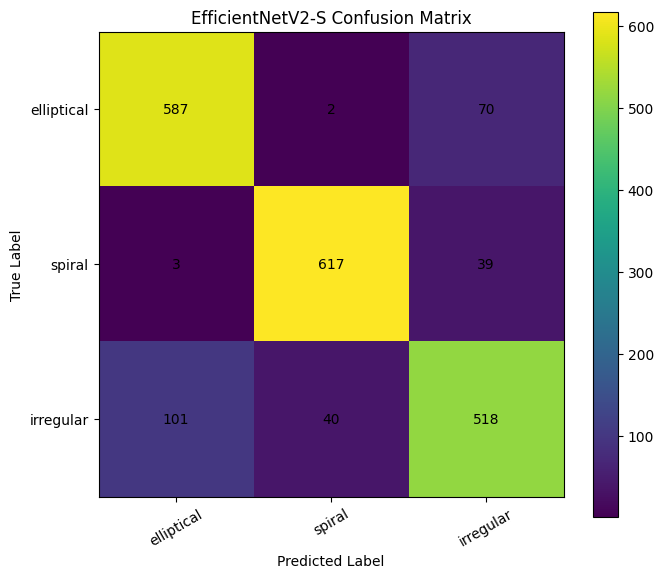

In [25]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(
    figsize=(7, 6)
)

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    range(len(classes)),
    classes,
    rotation=30
)

plt.yticks(
    range(len(classes)),
    classes
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.title(
    "EfficientNetV2-S Confusion Matrix"
)

for i in range(len(classes)):
    for j in range(len(classes)):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

CONFUSION_PATH = os.path.join(
    RESULTS_DIR,
    "confusion_matrix.png"
)

plt.savefig(
    CONFUSION_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 18. Training History

Training and validation accuracy and loss from Stage 1 and Stage 2 are combined into a single history. Accuracy and loss curves are plotted across both stages, with the start of fine-tuning marked on each graph.


In [26]:
train_accuracy = (
    history_stage1.history["accuracy"]
    +
    history_stage2.history["accuracy"]
)

val_accuracy = (
    history_stage1.history["val_accuracy"]
    +
    history_stage2.history["val_accuracy"]
)

train_loss = (
    history_stage1.history["loss"]
    +
    history_stage2.history["loss"]
)

val_loss = (
    history_stage1.history["val_loss"]
    +
    history_stage2.history["val_loss"]
)

epochs = range(
    1,
    len(train_accuracy) + 1
)

fine_tune_start = (
    len(
        history_stage1.history["accuracy"]
    )
)

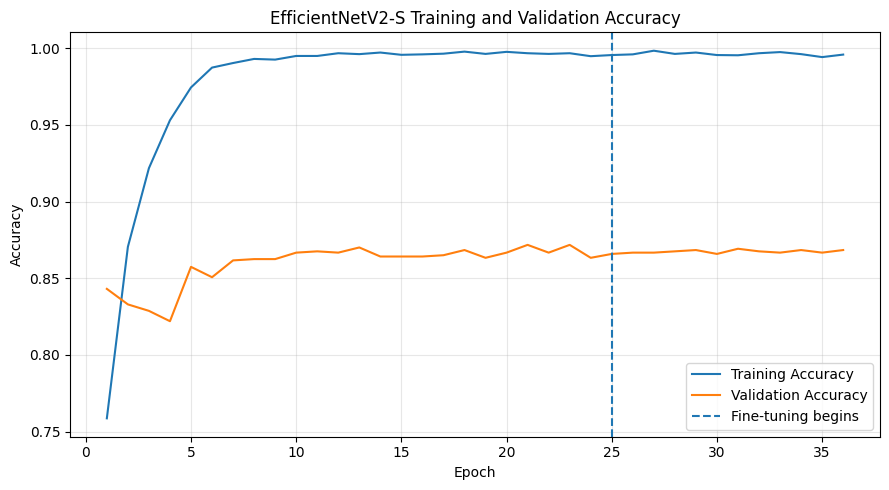

In [27]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    epochs,
    train_accuracy,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracy,
    label="Validation Accuracy"
)

plt.axvline(
    fine_tune_start,
    linestyle="--",
    label="Fine-tuning begins"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "EfficientNetV2-S Training and Validation Accuracy"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

ACCURACY_GRAPH_PATH = os.path.join(
    RESULTS_DIR,
    "accuracy_curve.png"
)

plt.savefig(
    ACCURACY_GRAPH_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

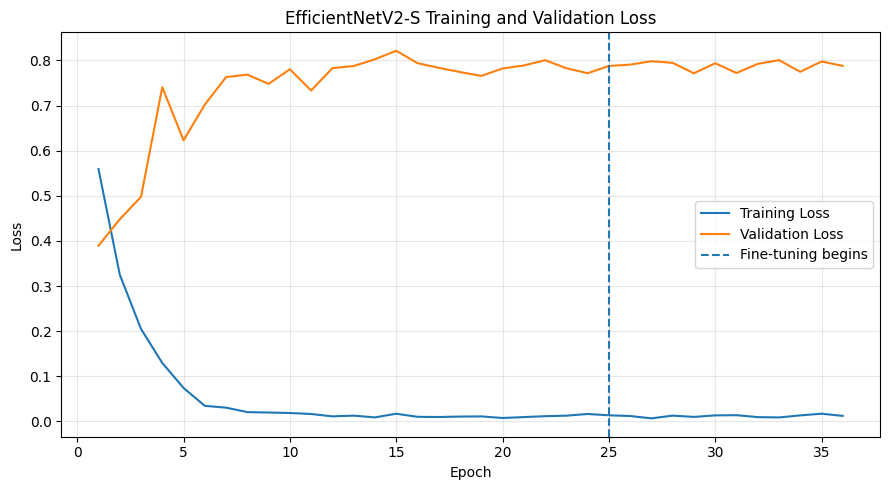

In [28]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    epochs,
    train_loss,
    label="Training Loss"
)

plt.plot(
    epochs,
    val_loss,
    label="Validation Loss"
)

plt.axvline(
    fine_tune_start,
    linestyle="--",
    label="Fine-tuning begins"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "EfficientNetV2-S Training and Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

LOSS_GRAPH_PATH = os.path.join(
    RESULTS_DIR,
    "loss_curve.png"
)

plt.savefig(
    LOSS_GRAPH_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 19. Save Training History

The combined training history is stored in a DataFrame containing accuracy and loss values for both training and validation sets. The results are saved as a CSV file for later analysis and reporting.


In [29]:
history_df = pd.DataFrame({
    "epoch": list(epochs),
    "train_accuracy": train_accuracy,
    "validation_accuracy": val_accuracy,
    "train_loss": train_loss,
    "validation_loss": val_loss
})

history_path = os.path.join(
    RESULTS_DIR,
    "training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)

print(
    "Saved:",
    history_path
)

Saved: /kaggle/working/GalaxyZoo_EfficientNetV2-S_Clean/results_7782/training_history.csv


## 20. Save Experiment Summary

Key dataset, training, performance, and model configuration details are collected into a single summary. The results are saved as a JSON file to provide a compact record of the complete experiment.


In [30]:
import json

best_val_accuracy = max(stage1_best_val_acc, stage2_best_val_acc)
combined_val_accuracy = (
    history_stage1.history["val_accuracy"]
    + history_stage2.history["val_accuracy"]
)
best_epoch = int(np.argmax(combined_val_accuracy) + 1)
total_training_minutes = (stage1_time + stage2_time) / 60

summary = {
    "model": "EfficientNetV2-S full fine-tune",
    "dataset": "Galaxy Zoo 2",
    "classes": classes,
    "images_per_class": int(N_PER_CLASS),
    "input_size": list(IMG_SIZE),
    "batch_size": int(BATCH_SIZE),
    "threshold": float(THRESHOLD),
    "random_seed": int(SEED),
    "test_accuracy": float(accuracy),
    "test_accuracy_percent": float(accuracy * 100),
    "test_loss": float(test_loss),
    "macro_precision": float(macro_precision),
    "macro_recall": float(macro_recall),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),
    "best_validation_accuracy": float(best_val_accuracy),
    "best_epoch": best_epoch,
    "training_time_minutes": float(total_training_minutes),
    "fine_tuned_layers": int(FINE_TUNE_LAYERS),
    "total_parameters": int(best_model.count_params()),
}

SUMMARY_PATH = RESULTS_DIR / "EfficientNetV2-S_summary.json"
with open(SUMMARY_PATH, "w") as f:
    json.dump(summary, f, indent=4)

print(json.dumps(summary, indent=4))


{
    "model": "EfficientNetV2-S full fine-tune",
    "dataset": "Galaxy Zoo 2",
    "classes": [
        "elliptical",
        "spiral",
        "irregular"
    ],
    "images_per_class": 3295,
    "input_size": [
        256,
        256
    ],
    "batch_size": 32,
    "threshold": 0.8,
    "random_seed": 42,
    "test_accuracy": 0.8710166919575114,
    "test_accuracy_percent": 87.10166919575114,
    "test_loss": 0.734698474407196,
    "macro_precision": 0.8706389529532265,
    "macro_recall": 0.8710166919575114,
    "macro_f1": 0.8704984855939496,
    "weighted_f1": 0.8704984855939497,
    "best_validation_accuracy": 0.8717299699783325,
    "best_epoch": 21,
    "training_time_minutes": 36.1303461710612,
    "fine_tuned_layers": 514,
    "total_parameters": 20335203
}


## 21. Generate Test Predictions

Predictions are generated for the test images and organized into a DataFrame with true labels, predicted labels, confidence scores, and correctness. The resulting predictions are saved as a CSV file for further analysis.


In [31]:
filenames = [os.path.basename(file_path) for file_path in test_file_paths]

prediction_df = pd.DataFrame({
    "filename": filenames,
    "true_class_index": y_true,
    "predicted_class_index": y_pred,
    "true_class": [classes[i] for i in y_true],
    "predicted_class": [classes[i] for i in y_pred],
    "confidence": np.max(prediction_probabilities, axis=1),
})

prediction_df["correct"] = (
    prediction_df["true_class"] == prediction_df["predicted_class"]
)

prediction_path = RESULTS_DIR / "test_predictions.csv"
prediction_df.to_csv(prediction_path, index=False)
display(prediction_df.head())


,filename,true_class_index,predicted_class_index,true_class,predicted_class,confidence,correct
0,1000.jpg,0,0,elliptical,elliptical,0.999777,True
1,100907.jpg,0,0,elliptical,elliptical,0.999959,True
2,101697.jpg,0,0,elliptical,elliptical,0.977421,True
3,10180.jpg,0,0,elliptical,elliptical,0.999822,True
4,101819.jpg,0,0,elliptical,elliptical,0.999913,True


## 22. Inspect Incorrect Predictions

Incorrect predictions are isolated and sorted by confidence to support error analysis. The 20 highest-confidence mistakes are displayed for closer inspection.


In [32]:
wrong_predictions = (
    prediction_df[
        prediction_df["correct"] == False
    ]
    .sort_values(
        "confidence",
        ascending=False
    )
)

print(
    "Total mistakes:",
    len(wrong_predictions)
)

display(
    wrong_predictions.head(20)
)

Total mistakes: 255


,filename,true_class_index,predicted_class_index,true_class,predicted_class,confidence,correct
1634,221317.jpg,2,0,irregular,elliptical,1.000000,False
1345,108434.jpg,2,0,irregular,elliptical,1.000000,False
1889,63008.jpg,2,0,irregular,elliptical,0.999999,False
1943,86329.jpg,2,0,irregular,elliptical,0.999999,False
1577,200263.jpg,2,0,irregular,elliptical,0.999999,False
1049,25651.jpg,1,2,spiral,irregular,0.999998,False
1857,49273.jpg,2,0,irregular,elliptical,0.999998,False
1576,200224.jpg,2,0,irregular,elliptical,0.999998,False
1223,60908.jpg,1,2,spiral,irregular,0.999996,False
1877,57071.jpg,2,0,irregular,elliptical,0.999993,False


## 23. Test-Time Augmentation Evaluation

Test-time augmentation evaluates each test image using five different views and averages their predicted probabilities. The final TTA predictions are used to calculate test accuracy and a classification report without additional model training.


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

def predict_with_tta(model, test_ds):
    y_true = []
    all_batch_probs = []

    print("Calculating TTA predictions...")
    for images, labels in test_ds:
        y_true.extend(labels.numpy())
        
        aug_versions = [
            images,
            tf.image.flip_left_right(images),
            tf.image.flip_up_down(images),
            tf.image.rot90(images, k=1),
            tf.image.rot90(images, k=2)
        ]
        

        version_probs = [model.predict(aug_img, verbose=0) for aug_img in aug_versions]

        avg_probs = np.mean(version_probs, axis=0)
        all_batch_probs.append(avg_probs)

    all_probs = np.vstack(all_batch_probs)
    y_pred_tta = np.argmax(all_probs, axis=1)
    
    return np.array(y_true), y_pred_tta

y_true, y_pred_tta = predict_with_tta(best_model, test_dataset)

tta_acc = accuracy_score(y_true, y_pred_tta)
print(f"\n==========================================")
print(f"TTA Test Accuracy: {tta_acc * 100:.2f}%")
print(f"==========================================\n")

print("--- Classification Report (TTA) ---")
print(classification_report(y_true, y_pred_tta, target_names=classes, digits=4))

Calculating TTA predictions...

TTA Test Accuracy: 88.92%

--- Classification Report (TTA) ---
              precision    recall  f1-score   support

  elliptical     0.8701    0.9044    0.8869       659
      spiral     0.9415    0.9530    0.9472       659
   irregular     0.8544    0.8103    0.8318       659

    accuracy                         0.8892      1977
   macro avg     0.8887    0.8892    0.8886      1977
weighted avg     0.8887    0.8892    0.8886      1977



## 24. Validation Test-Time Augmentation

The same five-view TTA strategy is applied to the validation set. The averaged predictions are used to calculate validation accuracy and generate a classification report for comparison with the standard validation results.


In [ ]:
def evaluate_val_with_tta(model, val_ds):
    y_true = []
    all_batch_probs = []

    print("Calculating TTA predictions for the validation set...")
    for images, labels in val_ds:
        y_true.extend(labels.numpy())
        
        aug_versions = [
            images,
            tf.image.flip_left_right(images),
            tf.image.flip_up_down(images),
            tf.image.rot90(images, k=1),
            tf.image.rot90(images, k=2)
        ]
        
        version_probs = [model.predict(aug_img, verbose=0) for aug_img in aug_versions]
        
        avg_probs = np.mean(version_probs, axis=0)
        all_batch_probs.append(avg_probs)

    all_probs = np.vstack(all_batch_probs)
    y_pred_val_tta = np.argmax(all_probs, axis=1)
    
    return np.array(y_true), y_pred_val_tta

y_val_true, y_val_pred_tta = evaluate_val_with_tta(best_model, validation_dataset)

val_acc_tta = accuracy_score(y_val_true, y_val_pred_tta)

print(f"\n==========================================")
print(f"TTA Validation Accuracy: {val_acc_tta * 100:.2f}%")
print(f"==========================================\n")

print("--- Validation Classification Report (TTA) ---")
print(classification_report(y_val_true, y_val_pred_tta, target_names=classes, digits=4))

Calculating TTA predictions for the validation set...

TTA Validation Accuracy: 87.34%

--- Validation Classification Report (TTA) ---
              precision    recall  f1-score   support

  elliptical     0.8564    0.8911    0.8734       395
      spiral     0.9369    0.9392    0.9381       395
   irregular     0.8254    0.7899    0.8072       395

    accuracy                         0.8734      1185
   macro avg     0.8729    0.8734    0.8729      1185
weighted avg     0.8729    0.8734    0.8729      1185
